In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# =============================================================================
# PROJECT ITERATION 2 — Smart Resume-Job Matching System with Innovations
# =============================================================================
# Environment  : Kaggle Notebook (GPU recommended)
# Language      : English (all outputs)
# Date          : 2026-02-11
# =============================================================================

# =====================================================================
#  PHASE 0 — SETUP & IMPORTS
# =====================================================================

import json, os, re, random, warnings, time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("deep")

print("=" * 70)
print("  PHASE 0 — Environment Ready")
print("=" * 70)
print(f"  spaCy version : {spacy.__version__}")
print(f"  NumPy version : {np.__version__}")
print(f"  Pandas version: {pd.__version__}")
print("=" * 70)


  PHASE 0 — Environment Ready
  spaCy version : 3.8.7
  NumPy version : 2.0.2
  Pandas version: 2.2.2


In [2]:
# =====================================================================
#  PHASE 0.2 — Define Paths & Load NER Data
# =====================================================================

NER_DATA_DIR   = "/kaggle/input/datasets/aabdollahii/ner-training-dataset"
INDEED_DATA_DIR = "/kaggle/input/datasets/aabdollahii/job-recom-dataset"
MODEL_SAVE_DIR  = "/kaggle/working/ner_model_v2"

# Verify paths
for p, label in [(NER_DATA_DIR, "NER Data"), (INDEED_DATA_DIR, "Indeed Data")]:
    if os.path.isdir(p):
        print(f"  [OK] {label} found at {p}  -> {os.listdir(p)}")
    else:
        print(f"  [!!] {label} NOT found at {p}. Adjust the path.")

# Load NER JSON (line-delimited)
def load_ner_json(filepath):
    data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

train_raw = load_ner_json(os.path.join(NER_DATA_DIR, "traindata.json"))
test_raw  = load_ner_json(os.path.join(NER_DATA_DIR, "testdata.json"))

print(f"\n  NER Training samples : {len(train_raw)}")
print(f"  NER Testing samples  : {len(test_raw)}")


  [OK] NER Data found at /kaggle/input/datasets/aabdollahii/ner-training-dataset  -> ['traindata.json', 'testdata.json']
  [OK] Indeed Data found at /kaggle/input/datasets/aabdollahii/job-recom-dataset  -> ['datascientist.json', 'dataengineer.json', 'phpdeveloper.json', 'javadeveloper.json', 'backenddeveloper.json']

  NER Training samples : 200
  NER Testing samples  : 20


In [3]:
# =====================================================================
#  PHASE 0.3 — Load Indeed Job Data
# =====================================================================

indeed_files = [f for f in os.listdir(INDEED_DATA_DIR) if f.endswith(".json")]
indeed_jobs = []

for fname in sorted(indeed_files):
    fpath = os.path.join(INDEED_DATA_DIR, fname)
    with open(fpath, "r", encoding="utf-8") as f:
        content = json.load(f)
    category = fname.replace(".json", "")
    for job in content:
        job["category"] = category
        indeed_jobs.append(job)

print(f"  Indeed job files loaded : {len(indeed_files)}")
print(f"  Total job postings     : {len(indeed_jobs)}")
print(f"  Categories             : {sorted(set(j['category'] for j in indeed_jobs))}")

# Quick peek
if indeed_jobs:
    sample = indeed_jobs[0]
    print(f"\n  Sample job title   : {sample.get('title', 'N/A')}")
    print(f"  Sample company     : {sample.get('company', 'N/A')}")
    print(f"  Sample location    : {sample.get('location', 'N/A')}")
    print(f"  Description preview: {sample.get('desc', '')[:200]}...")


  Indeed job files loaded : 5
  Total job postings     : 145
  Categories             : ['backenddeveloper', 'dataengineer', 'datascientist', 'javadeveloper', 'phpdeveloper']

  Sample job title   : Senior BackEnd Developer - Python
  Sample company     : Zid
  Sample location    : Riyadh
  Description preview: Company Description

Who we are?

Become a Zider Tech member and join this amazing company that is on top of the e-commerce game! Join a company that is not only growing but having fun while doing it....


In [5]:
# =====================================================================
#  PHASE 0.4 — Convert NER Data to spaCy Format (FIXED)
# =====================================================================

import re

ENTITY_LABELS = set()

# --- trim_entity_spans from spaCy issue #3558 ---
def trim_entity_spans(data: list):
    """Removes leading and trailing white spaces from entity spans."""
    invalid_span_tokens = re.compile(r'\s')
    cleaned_data = []
    for text, annotations in data:
        entities = annotations['entities']
        valid_entities = []
        for start, end, label in entities:
            valid_start = start
            valid_end = end
            while valid_start < len(text) and invalid_span_tokens.match(text[valid_start]):
                valid_start += 1
            while valid_end > 1 and invalid_span_tokens.match(text[valid_end - 1]):
                valid_end -= 1
            valid_entities.append([valid_start, valid_end, label])
        cleaned_data.append([text, {'entities': valid_entities}])
    return cleaned_data

def remove_overlaps(entities):
    """Remove overlapping spans — keep longest when overlap occurs."""
    if not entities:
        return entities
    sorted_ents = sorted(entities, key=lambda x: (x[0], -(x[1] - x[0])))
    cleaned = [sorted_ents[0]]
    for ent in sorted_ents[1:]:
        prev = cleaned[-1]
        if ent[0] >= prev[1]:
            cleaned.append(ent)
        elif (ent[1] - ent[0]) > (prev[1] - prev[0]):
            cleaned[-1] = ent
    return cleaned

def parse_annotations(raw_data):
    """Convert raw JSON annotations to spaCy training tuples."""
    parsed = []
    for item in raw_data:
        try:
            text = item['content']
            entities = []
            if 'annotation' in item and item['annotation'] is not None:
                for ann in item['annotation']:
                    # handle both list of labels or a single label
                    labels = ann['label']
                    if not isinstance(labels, list):
                        labels = [labels]
                    if len(labels) == 0:
                        continue

                    point = ann['points'][0]
                    for label in labels:
                        ENTITY_LABELS.add(label)
                        # dataturks indices are both inclusive [start, end]
                        # but spaCy needs [start, end)
                        entities.append((point['start'], point['end'] + 1, label))

            entities = remove_overlaps(entities)
            parsed.append((text, {"entities": entities}))
        except Exception as e:
            logging.exception("Unable to process item: " + str(e))
            continue

    return parsed

train_data = parse_annotations(train_raw)
test_data  = parse_annotations(test_raw)

# trim whitespace from entity spans
train_data = trim_entity_spans(train_data)
test_data  = trim_entity_spans(test_data)

ENTITY_LABELS = sorted(ENTITY_LABELS)

print(f"  Entity labels ({len(ENTITY_LABELS)}): {ENTITY_LABELS}")

# Entity distribution in training data
train_ent_counts = Counter()
for _, ann in train_data:
    for s, e, label in ann["entities"]:
        train_ent_counts[label] += 1

print(f"\n  Training entity distribution:")
for label, count in train_ent_counts.most_common():
    print(f"    {label:30s} : {count:4d}")


  Entity labels (11): ['College Name', 'Companies worked at', 'Degree', 'Designation', 'Email Address', 'Graduation Year', 'Location', 'Name', 'Skills', 'UNKNOWN', 'Years of Experience']

  Training entity distribution:
    Companies worked at            :  618
    Designation                    :  458
    Skills                         :  401
    Location                       :  372
    College Name                   :  289
    Degree                         :  267
    Email Address                  :  228
    Graduation Year                :  218
    Name                           :  205
    Years of Experience            :   38
    UNKNOWN                        :    2


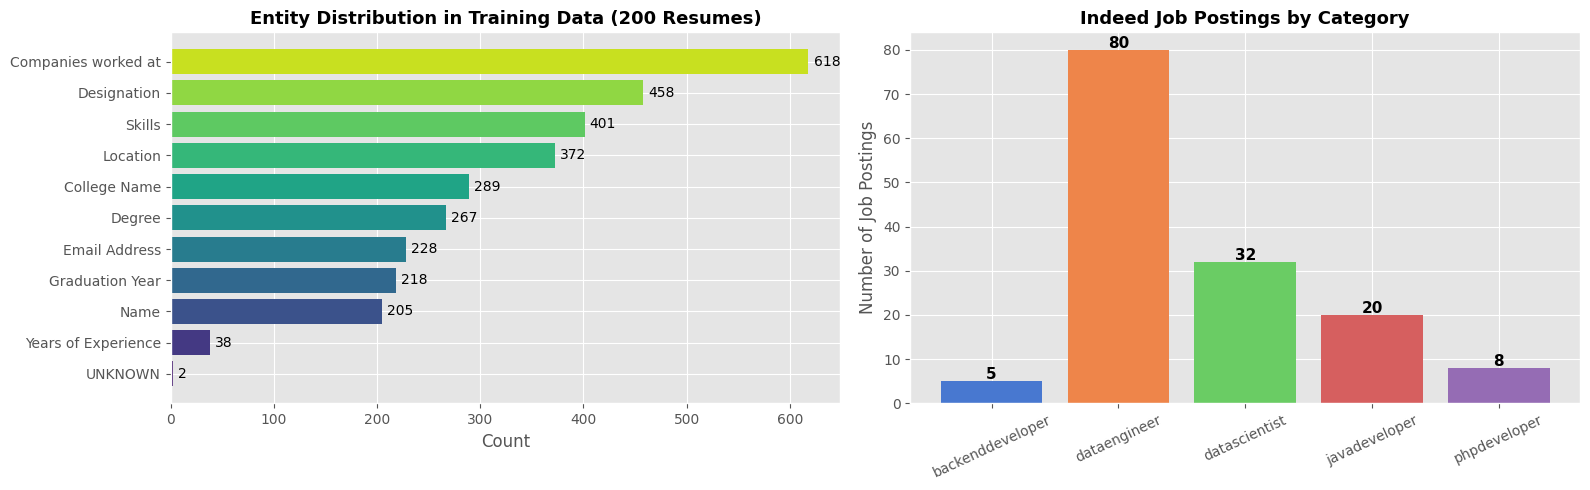


  [Phase 0 Complete]


In [6]:
# =====================================================================
#  PHASE 0.5 — Data Overview Visualization
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Entity distribution in training data ---
labels_sorted = [x[0] for x in train_ent_counts.most_common()]
counts_sorted = [x[1] for x in train_ent_counts.most_common()]

ax1 = axes[0]
bars = ax1.barh(labels_sorted[::-1], counts_sorted[::-1],
                color=sns.color_palette("viridis", len(labels_sorted)))
ax1.set_xlabel("Count", fontsize=12)
ax1.set_title("Entity Distribution in Training Data (200 Resumes)",
              fontsize=13, fontweight="bold")
for bar, val in zip(bars, counts_sorted[::-1]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=10)

# --- Right: Indeed jobs per category ---
cat_counts = Counter(j["category"] for j in indeed_jobs)
ax2 = axes[1]
cats = list(cat_counts.keys())
cat_vals = list(cat_counts.values())
bars2 = ax2.bar(cats, cat_vals, color=sns.color_palette("muted", len(cats)))
ax2.set_ylabel("Number of Job Postings", fontsize=12)
ax2.set_title("Indeed Job Postings by Category", fontsize=13, fontweight="bold")
ax2.tick_params(axis="x", rotation=25)
for bar, val in zip(bars2, cat_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/phase0_data_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Phase 0 Complete]")


In [ ]:
# =====================================================================
#  PHASE 1 — NER MODEL TRAINING
# =====================================================================
print("=" * 70)
print("  PHASE 1 — NER Model Training")
print("=" * 70)

# --- 1.1 Create blank model & add NER pipe ---
nlp = spacy.blank("en")
ner = nlp.add_pipe("ner", last=True)

for label in ENTITY_LABELS:
    ner.add_label(label)

print(f"  Pipeline : {nlp.pipe_names}")
print(f"  Labels   : {ENTITY_LABELS}")

# --- 1.2 Training configuration ---
N_ITER     = 30
DROPOUT    = 0.35
BATCH_SIZES = compounding(4.0, 32.0, 1.001)

loss_history = []
best_loss = float("inf")

random.seed(42)
np.random.seed(42)

print(f"\n  Training for {N_ITER} iterations, dropout={DROPOUT}")
print(f"  {'Iter':>6s}  {'Loss':>12s}  {'Best':>12s}  {'Time(s)':>10s}")
print("  " + "-" * 48)

other_pipes = [pipe for pipe in nlp.pipe_names if pipe != "ner"]

with nlp.disable_pipes(*other_pipes):
    optimizer = nlp.begin_training()

    for iteration in range(1, N_ITER + 1):
        t0 = time.time()
        random.shuffle(train_data)
        losses = {}
        batches = minibatch(train_data, size=BATCH_SIZES)

        for batch in batches:
            examples = []
            for text, annotations in batch:
                doc = nlp.make_doc(text)
                try:
                    example = Example.from_dict(doc, annotations)
                    examples.append(example)
                except:
                    continue
            if examples:
                nlp.update(examples, drop=DROPOUT, losses=losses, sgd=optimizer)

        epoch_loss = losses.get("ner", 0.0)
        loss_history.append(epoch_loss)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
            nlp.to_disk(MODEL_SAVE_DIR)

        elapsed = time.time() - t0
        marker = " *" if epoch_loss <= best_loss else ""
        print(f"  {iteration:>6d}  {epoch_loss:>12.2f}  {best_loss:>12.2f}  {elapsed:>10.2f}{marker}")

print(f"\n  Training complete. Best loss: {best_loss:.2f}")
print(f"  Model saved to: {MODEL_SAVE_DIR}")


  PHASE 1 — NER Model Training
  Pipeline : ['ner']
  Labels   : ['College Name', 'Companies worked at', 'Degree', 'Designation', 'Email Address', 'Graduation Year', 'Location', 'Name', 'Skills', 'UNKNOWN', 'Years of Experience']

  Training for 30 iterations, dropout=0.35
    Iter          Loss          Best     Time(s)
  ------------------------------------------------
       1      29718.74      29718.74       21.84 *
       2       6785.83       6785.83       21.55 *
       3       5329.33       5329.33       21.66 *
